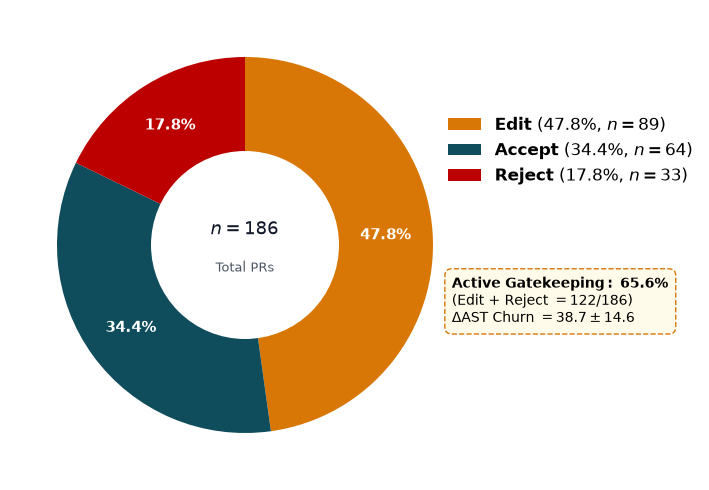

In [12]:
import matplotlib.pyplot as plt

# Data values
labels = ["Edit", "Accept", "Reject"]
sizes = [47.8, 34.4, 17.8]
counts = [89, 64, 33]
colors = ["#d97706", "#0f4c5c", "#bc0000"]  # Orange, Dark Teal, Red

# 1. Create figure and axis
fig, ax = plt.subplots(figsize=(7, 5), subplot_kw=dict(aspect="equal"))

# 2. Build the donut chart
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=None,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    colors=colors,
    pctdistance=0.75,
    textprops=dict(color="white", weight="bold", fontsize=11),
)

# 3. Draw the white center circle
centre_circle = plt.Circle((0, 0), 0.50, fc="white")
ax.add_artist(centre_circle)

# 4. Center text (Dedicated strictly to the total sample size)
ax.text(0, 0.08, r"$n = 186$", ha="center", va="center", fontsize=13, weight="bold", color="#111827")
ax.text(0, -0.12, "Total PRs", ha="center", va="center", fontsize=9, color="#4b5563")

# 5. Custom Legend
legend_labels = [
    f"$\\mathbf{{Edit}}$ ({sizes[0]}%, $n = {counts[0]}$)",
    f"$\\mathbf{{Accept}}$ ({sizes[1]}%, $n = {counts[1]}$)",
    f"$\\mathbf{{Reject}}$ ({sizes[2]}%, $n = {counts[2]}$)"
]
ax.legend(wedges, legend_labels, loc="center left", bbox_to_anchor=(0.9, 0.7), frameon=False, fontsize=12)

# 6. Callout annotation box for Active Gatekeeping (Highlighting the 65.6% here)
bbox_props = dict(boxstyle="round,pad=0.5", fc="#fffbeb", ec="#d97706", ls="--", linewidth=1)
ax.annotate(
    r"$\mathbf{Active\ Gatekeeping:\ 65.6\%}$" + "\n" +
    r"(Edit + Reject $= 122/186$)" + "\n" +
    r"$\Delta$AST Churn $= 38.7 \pm 14.6$",
    xy=(0.7, -0.3), xytext=(1.1, -0.3),
    bbox=bbox_props, fontsize=10, va="center"
)

plt.tight_layout()
plt.show()

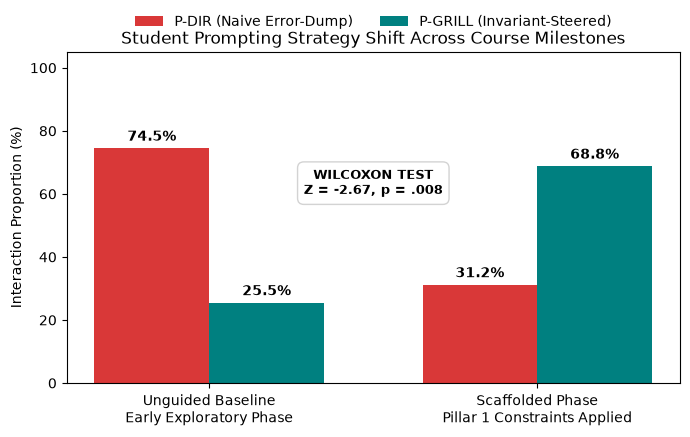

In [13]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Unguided Baseline\nEarly Exploratory Phase', 'Scaffolded Phase\nPillar 1 Constraints Applied']
p_dir = [74.5, 31.2]
p_grill = [25.5, 68.8]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4.5))
rects1 = ax.bar(x - width/2, p_dir, width, label='P-DIR (Naive Error-Dump)', color='#d93838')
rects2 = ax.bar(x + width/2, p_grill, width, label='P-GRILL (Invariant-Steered)', color='#008080')

ax.set_ylabel('Interaction Proportion (%)')
ax.set_title('Student Prompting Strategy Shift Across Course Milestones')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False)
ax.set_ylim(0, 105)

# Add text labels on bars
ax.bar_label(rects1, padding=3, fmt='%.1f%%', fontweight='bold')
ax.bar_label(rects2, padding=3, fmt='%.1f%%', fontweight='bold')

# Wilcoxon annotation box
ax.text(0.5, 60, 'WILCOXON TEST\nZ = -2.67, p = .008', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='lightgray'), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('prompt_shift_chart.pdf', format='pdf', bbox_inches='tight')